In [1]:
import pandas as pd
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
import auri
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [2]:
pd.options.display.float_format = '{:,.0f}'.format

In [3]:
# 데이터 타입 지정
dtype_dict = {
    '관리_건축물대장_PK': 'str',
    '대지_위치': 'str',
    '도로명_대지_위치': 'str',
    '건물_명': 'str',
    '시군구_코드': 'str',
    '법정동_코드': 'str',
    '대지_구분_코드': 'str',
    '번': 'str',
    '지': 'str',
    '특수지_명': 'str',
    '블록': 'str',
    '로트': 'str',
    '새주소_도로_코드': 'str',
    '새주소_법정동_코드': 'str',
    '새주소_지상지하_코드': 'str',
    '새주소_본_번': 'Int64',
    '새주소_부_번': 'Int64',
    '동_명칭': 'str',
    '층_구분_코드': 'str',
    '층_구분_코드_명': 'str',
    '층_번호': 'Int64',
    '층_번호_명': 'str',
    '구조_코드': 'str',
    '구조_코드_명': 'str',
    '기타_구조': 'str',
    '주_용도_코드': 'str',
    '주_용도_코드_명': 'str',
    '기타_용도': 'str',
    '면적(㎡)': 'float64',
    '주_부속_구분_코드': 'str',
    '주_부속_구분_코드_명': 'str',
    '면적_제외_여부': 'str',
    '생성_일자': 'str'
}

In [4]:
df = pd.read_csv(
    "data\국토교통부_건축물대장_층별개요+(2015년1월)\mart_djy_04.txt",
    encoding="utf-8-sig",
    names=dtype_dict.keys(),
    dtype=dtype_dict,
    index_col="관리_건축물대장_PK",
    skiprows=1,
    on_bad_lines="warn",
    delimiter="|",
)

In [5]:
df.columns

Index(['대지_위치', '도로명_대지_위치', '건물_명', '시군구_코드',
       '법정동_코드', '대지_구분_코드', '번', '지', '특수지_명', '블록',
       '로트', '새주소_도로_코드', '새주소_법정동_코드',
       '새주소_지상지하_코드', '새주소_본_번', '새주소_부_번', '동_명칭',
       '층_구분_코드', '층_구분_코드_명', '층_번호', '층_번호_명', '구조_코드',
       '구조_코드_명', '기타_구조', '주_용도_코드', '주_용도_코드_명',
       '기타_용도', '면적(㎡)', '주_부속_구분_코드', '주_부속_구분_코드_명',
       '면적_제외_여부', '생성_일자'],
      dtype='object')

In [6]:
len(df)

18595441

In [7]:
df.head()

,대지_위치,도로명_대지_위치,건물_명,시군구_코드,법정동_코드,대지_구분_코드,번,지,특수지_명,블록,...,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,면적(㎡),주_부속_구분_코드,주_부속_구분_코드_명,면적_제외_여부,생성_일자
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
26530-10017595102,부산광역시 사상구 주례동 67-9번지,부산광역시 사상구 주례로9번길 11,NaN,26530,10600,0,0067,0009,NaN,NaN,...,철근콘크리트구조,철근콘크리트구조,04402,사무소,제2종근린생활시설(사무소(주차장),23,0,주건축물,0,20100105
26530-10017595102,부산광역시 사상구 주례동 67-9번지,부산광역시 사상구 주례로9번길 11,NaN,26530,10600,0,0067,0009,NaN,NaN,...,철근콘크리트구조,철근콘크리트구조,04402,사무소,제2종근린생활시설(사무소),83,0,주건축물,0,20100105
26530-10017595102,부산광역시 사상구 주례동 67-9번지,부산광역시 사상구 주례로9번길 11,NaN,26530,10600,0,0067,0009,NaN,NaN,...,철근콘크리트구조,철근콘크리트구조,04402,사무소,제2종근린생활시설(사무소),60,0,주건축물,0,20100105
26530-10017595102,부산광역시 사상구 주례동 67-9번지,부산광역시 사상구 주례로9번길 11,NaN,26530,10600,0,0067,0009,NaN,NaN,...,철근콘크리트구조,철근콘크리트구조,04402,사무소,제2종근린생활시설(사무소),24,0,주건축물,0,20100105
26710-1085402,부산광역시 기장군 일광면 원리 1-33번지,부산광역시 기장군 일광면 원당길 10-13,NaN,26710,31030,0,0001,0033,NaN,NaN,...,철근콘크리트구조,철근콘크리트구조,01001,단독주택,단독주택,85,0,주건축물,0,20100105


### - 층별개요 컬럼 중 필요한 것 만 가져와서 데이터를 가볍게 함

In [8]:
df = df[['층_구분_코드', '층_구분_코드_명', '층_번호', '층_번호_명',
       '구조_코드', '구조_코드_명', '기타_구조', '주_용도_코드', '주_용도_코드_명', '기타_용도', '면적(㎡)',
       '주_부속_구분_코드', '면적_제외_여부', '생성_일자']]

In [9]:
df.head()

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,면적(㎡),주_부속_구분_코드,면적_제외_여부,생성_일자
관리_건축물대장_PK,,,,,,,,,,,,,,
26530-10017595102,20,지상,1,1층,21,철근콘크리트구조,철근콘크리트구조,04402,사무소,제2종근린생활시설(사무소(주차장),23,0,0,20100105
26530-10017595102,20,지상,3,3층,21,철근콘크리트구조,철근콘크리트구조,04402,사무소,제2종근린생활시설(사무소),83,0,0,20100105
26530-10017595102,20,지상,1,1층,21,철근콘크리트구조,철근콘크리트구조,04402,사무소,제2종근린생활시설(사무소),60,0,0,20100105
26530-10017595102,20,지상,4,4층,21,철근콘크리트구조,철근콘크리트구조,04402,사무소,제2종근린생활시설(사무소),24,0,0,20100105
26710-1085402,20,지상,1,1층,21,철근콘크리트구조,철근콘크리트구조,01001,단독주택,단독주택,85,0,0,20100105


### - 2015 층별개요 기초적인 통계 산출
1. 전국 건축물 층수 합 : 전체 레코드 수(합계, 지상층수 합계, 지하층수 합계) -> 산출방법 : 층_구분_코드 별로 레코드 수의 합계를 구함 -> value_counts() -> 20 : 지상, 10 : 지하, 30 : 옥탑, 21 : 복수층(하층), 22 : 복수층(상층), 40 : 각층(집합건축물 전유부 공용부분)

전국 건축물의 지상 층수의 합계는 16,795,131개 층이며, 지하 층수의 합계는 1,472,204개 층이다. 기타로 옥탑은 327,409개가 있으며, 복수층은 13개, 각층은 223개가 있다. 이를 모두 합한 전체 층의 합계는 18,595,441 층이다.

2. 층별 면적의 최대, 최소, 미기재 등 : 층별 면적이 미기재 된 것은 31,280개 층이다. 단일 층으로 최대 면적은 188,957,549.0의 경기 김포의 한강신도시 롯데캐슬의 지하층 부대시설이나 해당 건축물의 표제부 확인 결과 부용도로 대장을 확인할 수 없고 총괄표제부에 기록된 내용도 일치하는 항목을 찾을 수 없음. 따라서 부용도의 경우 층별개요의 연면적이 오류, 결측 등이 다 수 있는 것으로 추정

3. 건축물의 층 중 주용도 층은 16,910,020 개이며, 부용도 층은 1,679,972 개로 확인

4. 층별 면적이 표제부 또는 일반건축물대장의 연면적보다 큰 경우는 오기로 보는 것이 타당하여 레코드를 삭제할 필요가 있음


In [15]:
df.층_구분_코드.value_counts()

20    16795131
10     1472204
30      327409
40         223
22           7
21           6
Name: 층_구분_코드, dtype: int64

In [16]:
len(df)

18595441

In [17]:
len(df[df['면적(㎡)']<=0])

31280

In [18]:
df['면적(㎡)'].max()

188957549.0

In [19]:
df.주_부속_구분_코드.value_counts()

0    16910020
1     1679972
Name: 주_부속_구분_코드, dtype: int64

표제부파일 불러와서 데이터 프레임에 저장하기

In [10]:
# 데이터타입 딕셔너리 정의
dong_dtype_dict = {
    '관리_건축물대장_PK': 'str',
    '대장_구분_코드': 'str',
    '대장_구분_코드_명': 'str',
    '대장_종류_코드': 'str',
    '대장_종류_코드_명': 'str',
    '대지_위치': 'str',
    '도로명_대지_위치': 'str',
    '건물_명': 'str',
    '시군구_코드': 'str',
    '법정동_코드': 'str',
    '대지_구분_코드': 'str',
    '번': 'str',
    '지': 'str',
    '특수지_명': 'str',
    '블록': 'str',
    '로트': 'str',
    '외필지_수': 'Int64',
    'ETC_RCD_ITEM': 'str',
    '새주소_도로_코드': 'str',
    '새주소_법정동_코드': 'str',
    '새주소_지상지하_코드': 'str',
    '새주소_본_번': 'Int64',
    '새주소_부_번': 'Int64',
    '동_명칭': 'str',
    '주_부속_구분_코드': 'str',
    '주_부속_구분_코드_명': 'str',
    'SPCMT': 'str',
    '대지_면적(㎡)': 'float64',
    '건축_면적(㎡)': 'float64',
    '건폐율(%)': 'float64',
    '연면적(㎡)': 'float64',
    '용적률_산정_연면적(㎡)': 'float64',
    '용적률(%)': 'float64',
    '구조_코드': 'str',
    '구조_코드_명': 'str',
    '기타_구조': 'str',
    '주_용도_코드': 'str',
    '주_용도_코드_명': 'str',
    '기타_용도': 'str',
    '지붕_코드': 'str',
    '지붕_코드_명': 'str',
    '기타_지붕': 'str',
    '세대_수(세대)': 'Int64',
    '가구_수(가구)': 'Int64',
    '높이(m)': 'float64',
    '지상_층_수': 'Int64',
    '지하_층_수': 'Int64',
    '승용_승강기_수': 'Int64',
    '비상용_승강기_수': 'Int64',
    '부속_건축물_수': 'Int64',
    '부속_건축물_면적(㎡)': 'float64',
    '총_동_연면적(㎡)': 'float64',
    '옥내_기계식_대수(대)': 'Int64',
    '옥내_기계식_면적(㎡)': 'float64',
    '옥외_기계식_대수(대)': 'Int64',
    '옥외_기계식_면적(㎡)': 'float64',
    '옥내_자주식_대수(대)': 'Int64',
    '옥내_자주식_면적(㎡)': 'float64',
    '옥외_자주식_대수(대)': 'Int64',
    '옥외_자주식_면적(㎡)': 'float64',
    '허가_일': 'str',
    '착공_일': 'str',
    '사용승인_일': 'str',
    '허가번호_년': 'str',
    '허가번호_기관_코드': 'str',
    '허가번호_기관_코드_명': 'str',
    '허가번호_구분_코드': 'str',
    '허가번호_구분_코드_명': 'str',
    '호_수(호)': 'Int64',
    '에너지_효율등급': 'str',
    '에너지_절감율': 'float64',
    'EPI_점수': 'Int64',
    '친환경_건축물_등급': 'str',
    '친환경_건축물_인증점수': 'Int64',
    '지능형_건축물_등급': 'str',
    '지능형_건축물_인증점수': 'Int64',
    '생성_일자': 'str'
}

# CSV 파일을 데이터프레임으로 읽어오기
dong_df = pd.read_csv(
          "data\국토교통부_건축물대장_표제부+(2015년1월)\mart_djy_03.txt",
          encoding="utf-8-sig",
          names=dong_dtype_dict.keys(),
          dtype=dong_dtype_dict,
          index_col="관리_건축물대장_PK",
          skiprows=1,
          on_bad_lines="warn",
          delimiter="|",
          )

In [11]:
with pd.option_context("display.max_rows", None, "display.max_columns", 100):
    display(dong_df.head())

,대장_구분_코드,대장_구분_코드_명,대장_종류_코드,대장_종류_코드_명,대지_위치,도로명_대지_위치,건물_명,시군구_코드,법정동_코드,대지_구분_코드,번,지,특수지_명,블록,로트,외필지_수,ETC_RCD_ITEM,새주소_도로_코드,새주소_법정동_코드,새주소_지상지하_코드,새주소_본_번,새주소_부_번,동_명칭,주_부속_구분_코드,주_부속_구분_코드_명,SPCMT,대지_면적(㎡),건축_면적(㎡),건폐율(%),연면적(㎡),용적률_산정_연면적(㎡),용적률(%),구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,지붕_코드,지붕_코드_명,기타_지붕,세대_수(세대),가구_수(가구),높이(m),지상_층_수,지하_층_수,승용_승강기_수,비상용_승강기_수,부속_건축물_수,부속_건축물_면적(㎡),총_동_연면적(㎡),옥내_기계식_대수(대),옥내_기계식_면적(㎡),옥외_기계식_대수(대),옥외_기계식_면적(㎡),옥내_자주식_대수(대),옥내_자주식_면적(㎡),옥외_자주식_대수(대),옥외_자주식_면적(㎡),허가_일,착공_일,사용승인_일,허가번호_년,허가번호_기관_코드,허가번호_기관_코드_명,허가번호_구분_코드,허가번호_구분_코드_명,호_수(호),에너지_효율등급,에너지_절감율,EPI_점수,친환경_건축물_등급,친환경_건축물_인증점수,지능형_건축물_등급,지능형_건축물_인증점수,생성_일자
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
28170-2361502,1,일반,2,일반건축물,인천광역시 남구 도화동 597-37번지,인천광역시 남구 경인로252번안길 27,NaN,28170,10500,0,0597,0037,NaN,NaN,NaN,0,NaN,281704253053,10501,0,27,0,NaN,0,주건축물,NaN,0,0,0,41,0,0,11,벽돌구조,흙 벽돌조,01000,단독주택,주택,20,기와,세멘와즙,0,0,0,1,0,0,0,0,0,41,0,0,0,0,0,0,0,0,NaN,NaN,19850605,NaN,NaN,NaN,NaN,NaN,0,NaN,0,0,NaN,0,NaN,0,20090317
28170-2419002,1,일반,2,일반건축물,인천광역시 남구 도화동 698-1번지,인천광역시 남구 염전로 278,(염전길 224),28170,10500,0,0698,0001,NaN,NaN,NaN,1,NaN,281703150038,10501,0,278,0,2동,0,주건축물,NaN,0,775,0,775,775,0,11,벽돌구조,벽돌구조,17000,공장,공장,30,슬레이트,스레트평가,0,0,6,1,0,0,0,0,0,775,0,0,0,0,0,0,0,0,19730123,NaN,19760316,2006,NaN,NaN,1102,증축허가,0,NaN,0,0,NaN,0,NaN,0,20090317
28170-2419402,1,일반,2,일반건축물,인천광역시 남구 도화동 698-8번지,인천광역시 남구 장고개로50번길 55,NaN,28170,10500,0,0698,0008,NaN,NaN,NaN,0,NaN,281704253627,10501,0,55,0,NaN,0,주건축물,NaN,"1,326",919,69,992,992,75,31,일반철골구조,일반철골구조,17000,공장,공장,90,기타지붕,기타지붕,0,0,9,2,0,0,0,0,0,992,0,0,0,0,0,0,5,58,20061211,20061213,20070214,NaN,NaN,NaN,NaN,NaN,0,NaN,0,0,NaN,0,NaN,0,20090317
28170-2419602,1,일반,2,일반건축물,인천광역시 남구 도화동 699-11번지,인천광역시 남구 염전로 272-16,1,28170,10500,0,0699,0011,NaN,NaN,NaN,0,NaN,281703150038,10501,0,272,16,NaN,0,주건축물,NaN,"1,174",835,71,"1,899","1,899",162,31,일반철골구조,일반철골구조,17000,공장,공장,90,기타지붕,기타지붕,0,0,11,3,0,0,0,0,0,"1,899",0,0,0,0,0,0,9,104,20050926,20051026,20060410,2005,3510075,건축과,1101,신축허가,0,NaN,0,0,NaN,0,NaN,0,20090317
28170-2301102,1,일반,2,일반건축물,인천광역시 남구 도화동 498-1번지,NaN,NaN,28170,10500,0,0498,0001,NaN,NaN,NaN,0,NaN,NaN,NaN,0,<NA>,<NA>,NaN,0,주건축물,NaN,0,0,0,97,0,0,11,벽돌구조,"연와조, 세멘벽돌조",01000,단독주택,주택,10,(철근)콘크리트,스라브즙,0,0,0,2,1,0,0,1,5,97,0,0,0,0,0,0,0,0,19780914,NaN,19790122,NaN,NaN,NaN,NaN,NaN,0,NaN,0,0,NaN,0,NaN,0,20090317


In [13]:
dong_df.dtypes

대장_구분_코드            object
대장_구분_코드_명         object
대장_종류_코드            object
대장_종류_코드_명         object
대지_위치                 object
                           ...  
친환경_건축물_등급        object
친환경_건축물_인증점수     Int64
지능형_건축물_등급        object
지능형_건축물_인증점수     Int64
생성_일자                 object
Length: 76, dtype: object

표제부 파일에서 기초통계 생산하기
1. 전체 표제부/일반건축물의 동 수 : 7391576 동
2. 주 건축물, 부속건축물의 동 수 : 주(6882627 동), 부(508157 동)
3. 사용승인일 기재여부 : 유(6642714 동), 무(748862 동)
4. 사용승인일과 연면적이 모두 있는 동 수 : 6608129 동
5. 주 건축물이고 사용승인일, 연면적이 모두 있는 동 수 : 6280712 동

In [12]:
len(dong_df)

7391576

In [14]:
dong_df.주_부속_구분_코드.value_counts()

0    6882627
1     508157
Name: 주_부속_구분_코드, dtype: int64

In [16]:
dong_df.사용승인_일.isnull().value_counts()

False    6642714
True      748862
Name: 사용승인_일, dtype: int64

In [17]:
len(dong_df[(dong_df['연면적(㎡)']>0) & (~dong_df['사용승인_일'].isnull())])

6608129

In [18]:
len(dong_df[(dong_df['연면적(㎡)']>0) & (~dong_df['사용승인_일'].isnull()) & (dong_df['주_부속_구분_코드']=='0')])


6280712

표제부 파일 중 필요한 컬럼만 추출하여 데이터셋에 저장

In [20]:
dong_df = dong_df[['시군구_코드', '법정동_코드','주_부속_구분_코드', '주_부속_구분_코드_명', '대지_면적(㎡)',
       '건축_면적(㎡)', '건폐율(%)', '연면적(㎡)', '용적률_산정_연면적(㎡)', '용적률(%)', '구조_코드',
       '주_용도_코드', '주_용도_코드_명', '기타_용도', '총_동_연면적(㎡)','허가_일',
       '착공_일', '사용승인_일', '생성_일자']]
dong_df.columns

Index(['시군구_코드', '법정동_코드', '주_부속_구분_코드',
       '주_부속_구분_코드_명', '대지_면적(㎡)', '건축_면적(㎡)', '건폐율(%)',
       '연면적(㎡)', '용적률_산정_연면적(㎡)', '용적률(%)', '구조_코드',
       '주_용도_코드', '주_용도_코드_명', '기타_용도', '총_동_연면적(㎡)',
       '허가_일', '착공_일', '사용승인_일', '생성_일자'],
      dtype='object')

연도리스트 생성(1년부터 2023년까지, 2023개)

In [21]:
def generate_continuous_strings(start, end):
    """
    Generate a list of continuous strings from start to end.
    """
    year_list = [str(i).zfill(4) for i in range(start, end + 1)]
    return year_list

# Example usage:
year_list = generate_continuous_strings(1, 2023)
print(year_list)

['0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010', '0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020', '0021', '0022', '0023', '0024', '0025', '0026', '0027', '0028', '0029', '0030', '0031', '0032', '0033', '0034', '0035', '0036', '0037', '0038', '0039', '0040', '0041', '0042', '0043', '0044', '0045', '0046', '0047', '0048', '0049', '0050', '0051', '0052', '0053', '0054', '0055', '0056', '0057', '0058', '0059', '0060', '0061', '0062', '0063', '0064', '0065', '0066', '0067', '0068', '0069', '0070', '0071', '0072', '0073', '0074', '0075', '0076', '0077', '0078', '0079', '0080', '0081', '0082', '0083', '0084', '0085', '0086', '0087', '0088', '0089', '0090', '0091', '0092', '0093', '0094', '0095', '0096', '0097', '0098', '0099', '0100', '0101', '0102', '0103', '0104', '0105', '0106', '0107', '0108', '0109', '0110', '0111', '0112', '0113', '0114', '0115', '0116', '0117', '0118', '0119', '0120', '0121', '0122', '0123', '0124', '0125',

4자리수이나 연도가 아닐 가능성이 있는 월일형식 날짜 리스트 생성(0101부터 1231까지 366개)

In [22]:
from datetime import datetime, timedelta

def generate_date_strings():
    """
    Generate a list of date strings from January 1st to December 31st.
    """
    date_list = []

    # 시작 날짜 설정
    start_date = datetime(2024, 1, 1)

    # 12월 31일까지 반복
    while start_date.year == 2024:
        # 날짜를 '0101' 형식의 문자열로 변환하여 리스트에 추가
        date_str = start_date.strftime('%m%d')
        date_list.append(date_str)

        # 다음 날짜로 이동
        start_date += timedelta(days=1)

    return date_list

# Example usage:
date_list = generate_date_strings()
print(date_list)

['0101', '0102', '0103', '0104', '0105', '0106', '0107', '0108', '0109', '0110', '0111', '0112', '0113', '0114', '0115', '0116', '0117', '0118', '0119', '0120', '0121', '0122', '0123', '0124', '0125', '0126', '0127', '0128', '0129', '0130', '0131', '0201', '0202', '0203', '0204', '0205', '0206', '0207', '0208', '0209', '0210', '0211', '0212', '0213', '0214', '0215', '0216', '0217', '0218', '0219', '0220', '0221', '0222', '0223', '0224', '0225', '0226', '0227', '0228', '0229', '0301', '0302', '0303', '0304', '0305', '0306', '0307', '0308', '0309', '0310', '0311', '0312', '0313', '0314', '0315', '0316', '0317', '0318', '0319', '0320', '0321', '0322', '0323', '0324', '0325', '0326', '0327', '0328', '0329', '0330', '0331', '0401', '0402', '0403', '0404', '0405', '0406', '0407', '0408', '0409', '0410', '0411', '0412', '0413', '0414', '0415', '0416', '0417', '0418', '0419', '0420', '0421', '0422', '0423', '0424', '0425', '0426', '0427', '0428', '0429', '0430', '0501', '0502', '0503', '0504',

날짜일 가능성 배제를 위하여 연도리스트에서 날짜리스트 중복 삭제(최종 1657개)

In [23]:
def create_new_list(list1, list2):
    """
    Create a new list without duplicate items from both lists.
    """
    # 두 리스트를 합친 후 중복을 제거하여 새로운 리스트 생성
    new_list = [item for item in list1 + list2 if (list1 + list2).count(item) == 1]

    return new_list


# 중복값을 제외하고 새로운 리스트 생성
complete_year_list = create_new_list(year_list, date_list)

# 결과 출력
print("연도 추정 리스트:", complete_year_list)

연도 추정 리스트: ['0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010', '0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020', '0021', '0022', '0023', '0024', '0025', '0026', '0027', '0028', '0029', '0030', '0031', '0032', '0033', '0034', '0035', '0036', '0037', '0038', '0039', '0040', '0041', '0042', '0043', '0044', '0045', '0046', '0047', '0048', '0049', '0050', '0051', '0052', '0053', '0054', '0055', '0056', '0057', '0058', '0059', '0060', '0061', '0062', '0063', '0064', '0065', '0066', '0067', '0068', '0069', '0070', '0071', '0072', '0073', '0074', '0075', '0076', '0077', '0078', '0079', '0080', '0081', '0082', '0083', '0084', '0085', '0086', '0087', '0088', '0089', '0090', '0091', '0092', '0093', '0094', '0095', '0096', '0097', '0098', '0099', '0100', '0132', '0133', '0134', '0135', '0136', '0137', '0138', '0139', '0140', '0141', '0142', '0143', '0144', '0145', '0146', '0147', '0148', '0149', '0150', '0151', '0152', '0153', '0154', '015

사용승인일에서 4자리 사용승인연도를 추출하여 컬럼을 추가(year)하고, 연도추정리스트와 일치하는 지 여부에 대한 컬럼 추가(T_year)하여 새로운 데이터셋(dddf_new)생성

In [24]:
dong_df_new = dong_df.copy()

dong_df_new['year'] = dong_df_new.사용승인_일.str.slice(stop=4)
dong_df_new['T_year'] = dong_df_new['year'].isin(complete_year_list)
## dddf_new = dddf_new[(ddf_new['연면적(㎡)']>0)&(ddf_new['T_year'])&(ddf_new['주_부속_구분_코드'] == '0')]

# 결과 출력
dong_df_new.head()


,시군구_코드,법정동_코드,주_부속_구분_코드,주_부속_구분_코드_명,대지_면적(㎡),건축_면적(㎡),건폐율(%),연면적(㎡),용적률_산정_연면적(㎡),용적률(%),...,주_용도_코드,주_용도_코드_명,기타_용도,총_동_연면적(㎡),허가_일,착공_일,사용승인_일,생성_일자,year,T_year
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
28170-2361502,28170,10500,0,주건축물,0,0,0,41,0,0,...,01000,단독주택,주택,41,NaN,NaN,19850605,20090317,1985,True
28170-2419002,28170,10500,0,주건축물,0,775,0,775,775,0,...,17000,공장,공장,775,19730123,NaN,19760316,20090317,1976,True
28170-2419402,28170,10500,0,주건축물,"1,326",919,69,992,992,75,...,17000,공장,공장,992,20061211,20061213,20070214,20090317,2007,True
28170-2419602,28170,10500,0,주건축물,"1,174",835,71,"1,899","1,899",162,...,17000,공장,공장,"1,899",20050926,20051026,20060410,20090317,2006,True
28170-2301102,28170,10500,0,주건축물,0,0,0,97,0,0,...,01000,단독주택,주택,97,19780914,NaN,19790122,20090317,1979,True


표제부의 면적에 대한 3개의 칼럼(대지_면적(㎡), 건축_면적(㎡), 연면적(㎡))과 시군구_코드, 법정동_코드, 가공사용승인일(year) 등의 컬럼을 층별개요 컬럼에 관리_건축물대장_PK를 매개로 연결
['시군구_코드', '법정동_코드', '주_부속_구분_코드', '대지_면적(㎡)',
       '건축_면적(㎡)', '연면적(㎡)', '구조_코드',
       '주_용도_코드', '기타_용도', '총_동_연면적(㎡)', 'year', 'T_year']

In [25]:
dong_df_new.columns

Index(['시군구_코드', '법정동_코드', '주_부속_구분_코드',
       '주_부속_구분_코드_명', '대지_면적(㎡)', '건축_면적(㎡)', '건폐율(%)',
       '연면적(㎡)', '용적률_산정_연면적(㎡)', '용적률(%)', '구조_코드',
       '주_용도_코드', '주_용도_코드_명', '기타_용도', '총_동_연면적(㎡)',
       '허가_일', '착공_일', '사용승인_일', '생성_일자', 'year', 'T_year'],
      dtype='object')

층별개요에 표제부 조인

In [26]:
joined_df = df.join(dong_df_new[['시군구_코드', '법정동_코드', '주_부속_구분_코드', '대지_면적(㎡)',
       '건축_면적(㎡)', '연면적(㎡)', '구조_코드',
       '주_용도_코드', '기타_용도', '총_동_연면적(㎡)', 'year', 'T_year']], rsuffix='_dong')
joined_df.head()

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,주_부속_구분_코드_dong,대지_면적(㎡),건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
11110-100002,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,0,0,0,"1,152",11,02000,연립주택,"1,152",1986,True
11110-100002,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,0,0,"1,152",11,02000,연립주택,"1,152",1986,True
11110-100002,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,0,0,"1,152",11,02000,연립주택,"1,152",1986,True
11110-100002,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,0,0,"1,152",11,02000,연립주택,"1,152",1986,True
11110-1000102,20,지상,1,1층,11,벽돌구조,연와조,01001,단독주택,주택,...,0,0,0,163,11,01000,주택,163,1975,True


In [27]:
len(joined_df)

18595441

In [28]:
joined_df.columns

Index(['층_구분_코드', '층_구분_코드_명', '층_번호', '층_번호_명', '구조_코드',
       '구조_코드_명', '기타_구조', '주_용도_코드', '주_용도_코드_명',
       '기타_용도', '면적(㎡)', '주_부속_구분_코드', '면적_제외_여부',
       '생성_일자', '시군구_코드', '법정동_코드', '주_부속_구분_코드_dong',
       '대지_면적(㎡)', '건축_면적(㎡)', '연면적(㎡)', '구조_코드_dong',
       '주_용도_코드_dong', '기타_용도_dong', '총_동_연면적(㎡)', 'year',
       'T_year'],
      dtype='object')

최종 데이터프레임(18595441)에서 기초통계를 생산하고 이상치제거
-기초통계
1. 전체층수 중 사용승인일을 확인할 수 있는 층수 : T_year 컬럼이 True 인 행의 갯 수 : 17450143
- 이상치 및 결측치 제거순서
1. T_year 컬럼이 False인 행 제거 : 1145298
2. 주_부속_구분_코드 중 부속용도층 제거 : 1679972
2. 면적(㎡)이 0보다 작거나 같은 경우 제거 : 32333
3. 연면적(㎡)이 0보다 크고 면적(㎡)이 연면적(㎡)보다 큰 경우 제거 : 11569

-> 이상치 제거 데이터 16005940


joined_ddf[(joined_ddf['연면적(㎡)']>0) & (joined_ddf['면적(㎡)']>joined_ddf['연면적(㎡)'])]

In [29]:
joined_df['주_용도_코드'].dtype

dtype('O')

In [30]:
joined_df.T_year.value_counts()

True     17450143
False     1145298
Name: T_year, dtype: int64

In [31]:
joined_df.주_부속_구분_코드.value_counts()

0    16910020
1     1679972
Name: 주_부속_구분_코드, dtype: int64

In [32]:
len(joined_df[(joined_df['면적(㎡)']<=0)])

31280

In [33]:
len(joined_df[(joined_df['연면적(㎡)']>0) & (joined_df['면적(㎡)']>joined_df['연면적(㎡)'])])

11569

이상치 제거 후 새로운 데이터프레임 생성

In [34]:
filtered_joined_df = joined_df[
    (joined_df['T_year'] == True) 
   ## &
   ## (joined_ddf['주_부속_구분_코드'] != 1) &
   ## (joined_ddf['면적(㎡)'] > 0) &
   ## (joined_ddf['연면적(㎡)'] > 0 & joined_ddf['면적(㎡)'] <= joined_ddf['연면적(㎡)'])
]

In [35]:
filtered_joined_df = filtered_joined_df[
   (filtered_joined_df['주_부속_구분_코드'] == '0') 
]

In [36]:
filtered_joined_df = filtered_joined_df[
   (filtered_joined_df['면적(㎡)'] > 0)
]

In [37]:
filtered_joined_df = filtered_joined_df[
~((filtered_joined_df['연면적(㎡)'] > 0) & (filtered_joined_df['면적(㎡)'] > filtered_joined_df['연면적(㎡)']))
]

In [38]:
len(filtered_joined_df)

16005940

불리안 연산이기 때문에 여러 문제를 고민해야해

In [39]:
(joined_df['연면적(㎡)'] <= 0).value_counts()

False    18439075
True       156366
Name: 연면적(㎡), dtype: int64

최종 데이터셋에 면적값의 타당성 검증을 위하여 상위 10개 층을 가져와서 합리적인지 수작업으로 검토함, 콤마 점 오기 등 여전하게 발생됨. 상위 4위 오기로 확인됨
따라서, 오기를 배제하는 알고리즘을 검토함

In [40]:
with pd.option_context("display.max_rows", None, "display.max_columns", 100):
    display(filtered_joined_df.sort_values(by='면적(㎡)', ascending=False).head(100))

KeyboardInterrupt: 

In [41]:
type(filtered_joined_df)

pandas.core.frame.DataFrame

히스토그램을 통하여 면적 데이터 분포를 확인하였으며 현재의 데이터프레임에 데이터의 극단값이 존재하는 것으로 그림으로 확인할 수 있음

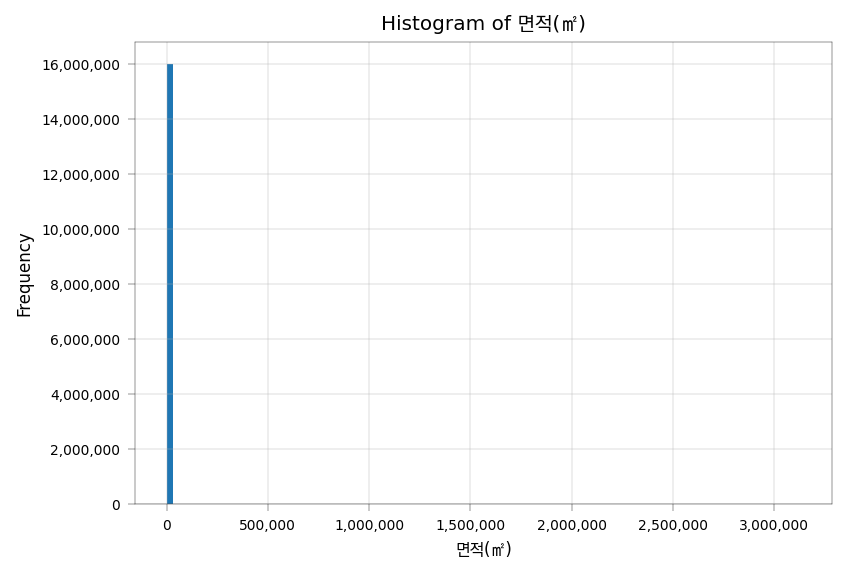

In [42]:
def plot_histogram(df, value_column, bins=100):
    """
    면적(㎡) 값을 100개의 구간으로 나누어 히스토그램을 그리는 함수.

    Parameters:
    df (dask.dataframe.DataFrame): 분석할 pandas
    
    value_column (str): 히스토그램을 그릴 값의 열 이름.
    bins (int): 히스토그램의 구간 개수 (기본값: 100).

    Returns:
    None
    """
    
    # 연면적(㎡) 값을 히스토그램으로 그리기
    ## plt.figure(figsize=(10, 6))
    ## plt.hist(df[value_column], bins=bins, color='skyblue', edgecolor='black')
    plt.figure()
    plt.hist(df[value_column], bins=bins)
    plt.title('Histogram of 면적(㎡)')
    plt.xlabel('면적(㎡)')
    plt.ylabel('Frequency')
    plt.grid(True)
    # Set the format of tick labels to non-scientific
    plt.ticklabel_format(style='plain', useOffset=False)
    # Format the tick labels with commas for thousands
    formatter = ticker.StrMethodFormatter('{x:,.0f}') # This formats the number with commas
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.show()

# 사용 예시
plot_histogram(filtered_joined_df, '면적(㎡)', bins=100)

이상치가 미치는 전체 데이터의 영향을 확인하기 위하여 면적의 상위값을 0.1%~15%까지 1%씩 가중하여 히스토그램 그림.

In [43]:
# 면적(㎡) 칼럼에 상용로그를 취하여 새로운 컬럼으로 저장
filtered_joined_df['상용로그_면적'] = np.log10(filtered_joined_df['면적(㎡)'])

In [44]:
filtered_joined_df['상용로그_면적'].dtype

dtype('float64')

In [45]:
with pd.option_context('display.float_format', '{:,.3f}'.format):
    display(filtered_joined_df['상용로그_면적'].describe())

count   16,005,940.000
mean             1.963
std              0.499
min             -2.155
25%              1.666
50%              1.937
75%              2.248
max              6.496
Name: 상용로그_면적, dtype: float64

In [46]:
with pd.option_context('display.float_format', '{:,.6f}'.format):
    display(filtered_joined_df['면적(㎡)'].describe())

count   16,005,940.000000
mean           189.367932
std          1,366.468479
min              0.007000
25%             46.370000
50%             86.520000
75%            177.000000
max      3,131,783.000000
Name: 면적(㎡), dtype: float64

In [47]:
with pd.option_context('display.float_format', '{:,.3f}'.format):
    display(filtered_joined_df.head())


,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,대지_면적(㎡),건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
11110-100002,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,0.000,0.000,"1,151.910",11,02000,연립주택,"1,151.910",1986,True,2.210
11110-100002,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0.000,0.000,"1,151.910",11,02000,연립주택,"1,151.910",1986,True,2.588
11110-100002,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0.000,0.000,"1,151.910",11,02000,연립주택,"1,151.910",1986,True,2.582
11110-100002,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0.000,0.000,"1,151.910",11,02000,연립주택,"1,151.910",1986,True,2.342
11110-1000102,20,지상,1,1층,11,벽돌구조,연와조,01001,단독주택,주택,...,0.000,0.000,163.340,11,01000,주택,163.240,1975,True,1.946


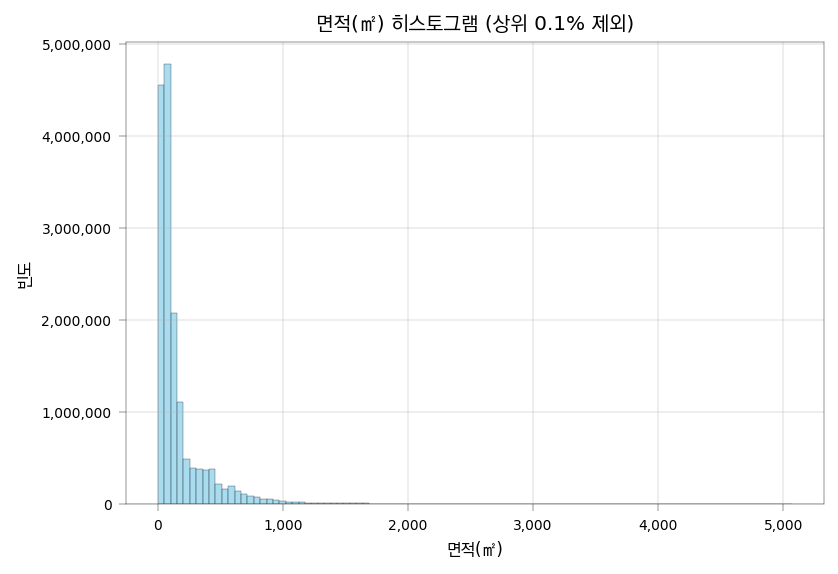

In [48]:
def plot_area_histogram(df):
    # 면적(㎡) 칼럼의 상위 0.1%를 제외한 데이터 추출
    quantile_999 = df['면적(㎡)'].quantile(0.999)
    filtered_df = df[df['면적(㎡)'] <= quantile_999]

    # 100개의 구간으로 나누기
    bins = np.linspace(filtered_df['면적(㎡)'].min(), filtered_df['면적(㎡)'].max(), 100)

    # 히스토그램 그리기
    plt.hist(filtered_df['면적(㎡)'], bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
    plt.xlabel('면적(㎡)')
    plt.ylabel('빈도')
    plt.title('면적(㎡) 히스토그램 (상위 0.1% 제외)')
    plt.grid(True)
    # Set the format of tick labels to non-scientific
    plt.ticklabel_format(style='plain', useOffset=False)
    # Format the tick labels with commas for thousands
    formatter = ticker.StrMethodFormatter('{x:,.0f}') # This formats the number with commas
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.show()


# 사용 예시
plot_area_histogram(filtered_joined_df)


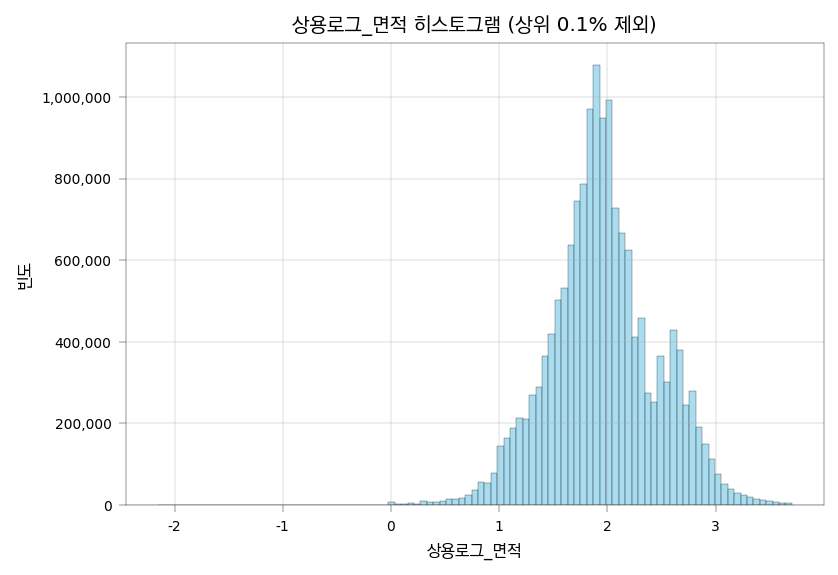

In [49]:
def plot_area_histogram(df, column_name):
    # 면적(㎡) 칼럼의 상위 0.1%를 제외한 데이터 추출
    quantile_999 = df[column_name].quantile(0.999)
    filtered_df = df[df[column_name] <= quantile_999]

    # 100개의 구간으로 나누기
    bins = np.linspace(filtered_df[column_name].min(), filtered_df[column_name].max(), 100)

    # 히스토그램 그리기
    plt.hist(filtered_df[column_name], bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
    plt.xlabel(column_name)
    plt.ylabel('빈도')
    plt.title(f'{column_name} 히스토그램 (상위 0.1% 제외)')
    plt.grid(True)
    # Set the format of tick labels to non-scientific
    plt.ticklabel_format(style='plain', useOffset=False)
    # Format the tick labels with commas for thousands
    formatter = ticker.StrMethodFormatter('{x:,.0f}') # This formats the number with commas
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.show()


# 사용 예시
plot_area_histogram(filtered_joined_df,'상용로그_면적')


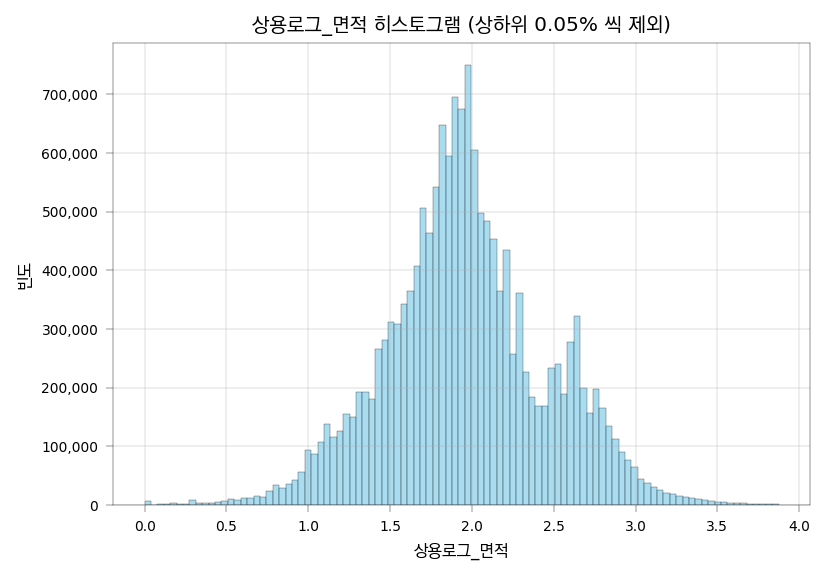

In [50]:
def plot_area_histogram(df, column_name):
    # 면적(㎡) 칼럼의 상하위 0.05% 씩을 제외한 데이터 추출
    quantile_low = df[column_name].quantile(0.0005)
    quantile_high = df[column_name].quantile(0.9995)
    filtered_df = df[(df[column_name] >= quantile_low) & (df[column_name] <= quantile_high)]

    # 100개의 구간으로 나누기
    bins = np.linspace(filtered_df[column_name].min(), filtered_df[column_name].max(), 100)

    # 히스토그램 그리기
    plt.hist(filtered_df[column_name], bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
    plt.xlabel(column_name)
    plt.ylabel('빈도')
    plt.title(f'{column_name} 히스토그램 (상하위 0.05% 씩 제외)')
    plt.grid(True)
    # Set the format of tick labels to non-scientific
    plt.ticklabel_format(style='plain', useOffset=False)
    # Format the tick labels with commas for thousands
    formatter = ticker.StrMethodFormatter('{x:,.0f}') # This formats the number with commas
    # plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.show()


# 사용 예시
plot_area_histogram(filtered_joined_df,'상용로그_면적')


상용로그_면적의 상하위 0.05% 이내의 값을 새로운 컬럼을 추가하여 표시

In [51]:
# filtered_joined_ddf에서 '상용로그_면적' 칼럼의 상위 및 하위 0.05% 값을 계산합니다.
upper_threshold = filtered_joined_df['상용로그_면적'].quantile(0.9995)  # 상위 0.05%
lower_threshold = filtered_joined_df['상용로그_면적'].quantile(0.0005)  # 하위 0.05%

# 'Upper_lower' 칼럼에 조건에 따라 상위/하위/일반을 지정합니다.
filtered_joined_df['Upper_lower'] = '일반'
filtered_joined_df.loc[filtered_joined_df['상용로그_면적'] > upper_threshold, 'Upper_lower'] = '상위'
filtered_joined_df.loc[filtered_joined_df['상용로그_면적'] < lower_threshold, 'Upper_lower'] = '하위'

# 결과를 확인합니다.
filtered_joined_df.head()

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
11110-100002,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,0,"1,152",11,02000,연립주택,"1,152",1986,True,2,일반
11110-100002,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,"1,152",11,02000,연립주택,"1,152",1986,True,3,일반
11110-100002,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,"1,152",11,02000,연립주택,"1,152",1986,True,3,일반
11110-100002,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,0,"1,152",11,02000,연립주택,"1,152",1986,True,2,일반
11110-1000102,20,지상,1,1층,11,벽돌구조,연와조,01001,단독주택,주택,...,0,163,11,01000,주택,163,1975,True,2,일반


In [52]:
filtered_joined_df.Upper_lower.value_counts()

일반    15994437
상위        8003
하위        3500
Name: Upper_lower, dtype: int64

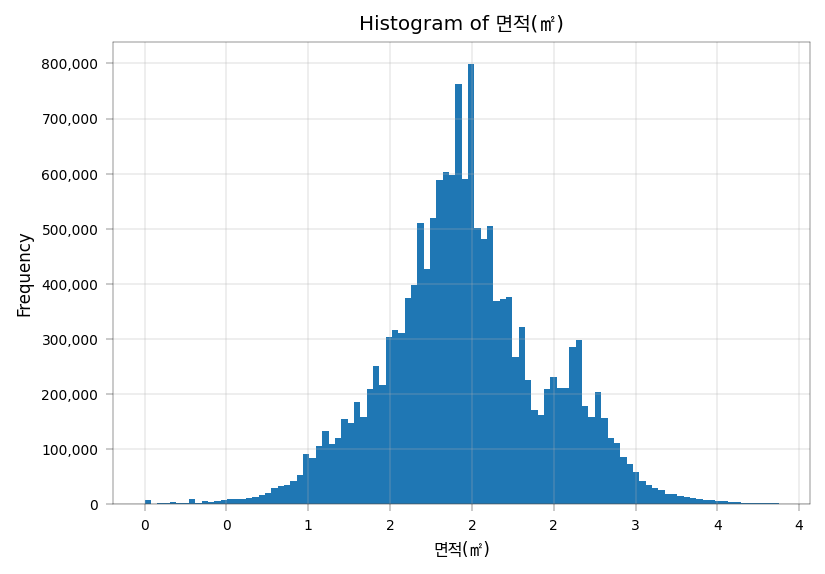

In [53]:
plot_histogram(filtered_joined_df[filtered_joined_df['Upper_lower'] =='일반'], '상용로그_면적', bins=100)

In [54]:
with pd.option_context("display.max_rows", None, "display.max_columns", 100):
    # display(filtered_joined_df[filtered_joined_df['Upper_lower'] == '일반'].nlargest(1, '면적(㎡)'))
    display(filtered_joined_df[filtered_joined_df['Upper_lower'] == '일반'].nsmallest(1, '면적(㎡)'))


,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,면적(㎡),주_부속_구분_코드,면적_제외_여부,생성_일자,시군구_코드,법정동_코드,주_부속_구분_코드_dong,대지_면적(㎡),건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,,,,,,,,
11110-1112102,10,지하,1,지1층,21,철근콘크리트구조,철근콘크리트조,03999,기타제1종근린생활시설,NaN,1,0,NaN,20141225,11110,14100,0,627,272,"1,212",21,03000,근린생활시설,"1,212",1986,True,0,일반


통계용 최종 데이터 프레임 완성!

In [55]:
f_df = filtered_joined_df[filtered_joined_df['Upper_lower'] == '일반']

In [56]:
f_df['면적(㎡)'].describe()

count   15,994,437
mean           182
std            320
min              1
25%             46
50%             86
75%            177
max          7,499
Name: 면적(㎡), dtype: float64

층별개요의 주_용도_코드는 세부용도를 기준으로 수록되어 있으며, 행정표준코드관리시스템에는 759개의 용도 코드가 있고, 현행 사용중인 코드는 5자리 534개이며, 2009년 일괄 개정되어 4자리 기존코드는 225개가 있음. 데이터 상으로는 698개가 있고, 코드 오기는 2개 층이 문자로 입력되어 오기로 확인.
주택 코드를 시리즈로 저장하고 이와 비교하여 각 층의 주택여부를 최종 데이터에 컬럼을 추가하여 표기

In [57]:
with pd.option_context("display.max_rows", None, "display.max_columns", 100):
    display(f_df.주_용도_코드.value_counts())

01001    5064676
02001    1903663
01003    1700725
02003     990807
03001     749288
04001     449713
18001     444738
04402     413110
17100     407731
21101     324946
03999     322324
04999     193871
02002     135204
04005     112969
02005     105384
17999     102773
15102      96486
04499      88040
04010      87665
21999      87327
03005      77444
03002      72030
14204      69521
14202      68118
18999      62478
14299      61460
06101      49536
03011      49096
20001      48239
11201      43716
03021      41179
10101      40403
03199      39173
04006      38781
15199      30880
01002      30555
10999      30000
10003      29799
10104      28349
18101      27997
04035      27410
19001      27173
10103      25712
03007      23757
03003      23678
17200      22976
17301      22324
16002      21015
04201      20739
02004      19636
11103      19490
04020      19236
04002      18710
04403      18691
10199      18675
10102      17684
09107      17659
11102      17208
04014      169

In [58]:
with pd.option_context("display.max_rows", None, "display.max_columns", 100):
    display(f_df[f_df['주_용도_코드'] == 'b0299'].head())

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,면적(㎡),주_부속_구분_코드,면적_제외_여부,생성_일자,시군구_코드,법정동_코드,주_부속_구분_코드_dong,대지_면적(㎡),건축_면적(㎡),연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,,,,,,,,
26110-298402,20,지상,3,3,21,철근콘크리트구조,철근콘크리트조,b0299,NaN,사무실,114,0,NaN,20110414,26110,10600,0,143,114,574,21,03000,"점포, 사무실 , 단독주택",574,1975,True,2,일반
26110-338002,20,지상,6,6,42,철골철근콘크리트구조,철골철근콘크리트,b0299,NaN,업무시설,528,0,NaN,20140415,26110,10700,0,739,585,"9,468",42,14000,"업무시설, 근린생활시설","9,468",1997,True,3,일반
26110-338002,20,지상,3,3,42,철골철근콘크리트구조,철골철근콘크리트,b0299,NaN,업무시설,453,0,NaN,20140415,26110,10700,0,739,585,"9,468",42,14000,"업무시설, 근린생활시설","9,468",1997,True,3,일반
26110-338002,20,지상,5,5,42,철골철근콘크리트구조,철골철근콘크리트,b0299,NaN,업무시설,528,0,NaN,20140415,26110,10700,0,739,585,"9,468",42,14000,"업무시설, 근린생활시설","9,468",1997,True,3,일반
26110-338002,20,지상,9,9,42,철골철근콘크리트구조,철골철근콘크리트,b0299,NaN,업무시설,466,0,NaN,20140415,26110,10700,0,739,585,"9,468",42,14000,"업무시설, 근린생활시설","9,468",1997,True,3,일반


In [59]:
h_list = [
    '01000', '01001', '01002', '01003', '01004', '01005', '01006', '01007', '01008', '02000', '02001', '02002', '02003', '02004', '02005', '02006', '02007', '02008', '02009', '02010', '02011',
    '1000', '1002', '1003', '1004', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007']
h_list

['01000',
 '01001',
 '01002',
 '01003',
 '01004',
 '01005',
 '01006',
 '01007',
 '01008',
 '02000',
 '02001',
 '02002',
 '02003',
 '02004',
 '02005',
 '02006',
 '02007',
 '02008',
 '02009',
 '02010',
 '02011',
 '1000',
 '1002',
 '1003',
 '1004',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007']

In [60]:
f_df['housing'] = f_df['주_용도_코드'].isin(h_list)
f_df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_13132\4022778981.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_df['housing'] = f_df['주_용도_코드'].isin(h_list)


,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,연면적(㎡),구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower,housing
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
11110-100002,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,"1,152",11,02000,연립주택,"1,152",1986,True,2,일반,True
11110-100002,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,"1,152",11,02000,연립주택,"1,152",1986,True,3,일반,True
11110-100002,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,"1,152",11,02000,연립주택,"1,152",1986,True,3,일반,True
11110-100002,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,"1,152",11,02000,연립주택,"1,152",1986,True,2,일반,True
11110-1000102,20,지상,1,1층,11,벽돌구조,연와조,01001,단독주택,주택,...,163,11,01000,주택,163,1975,True,2,일반,True


주거용도의 층수는 9983971이고, 전체면적은 1539244357.0952306이며, 층별 평균은 154.17155729871718임. 비주거용도의 층수는 6010466이며, 전체면적은 1364886147.7111475이며, 층별 평균은 227.08491283556842임.

In [61]:
f_df.housing.value_counts()

True     9983971
False    6010466
Name: housing, dtype: int64

In [62]:
f_df[f_df['housing']]['면적(㎡)'].sum()

1539244357.0952306

In [63]:
f_df[f_df['housing']]['면적(㎡)'].mean()

154.17155729871718

In [64]:
f_df[~f_df['housing']]['면적(㎡)'].sum()

1364886147.7111475

In [65]:
f_df[~f_df['housing']]['면적(㎡)'].mean()

227.08491283556842

각 층을 가중치로 2015년 1월 데이터 기준 당시 우리나라 건축물의 평균 연령은 24.76510643669417세이며, 평균 사용승인년도는 1990.3348935633057이다.
24년 6월 기준 평균연령은 27.90237718412368세이다.
면적을 기준으로 당시 우리나라 건축물의 평균 사용승인년도는  1997.4752837494711이며, 15년 1월 기준 평균연령은 17.624716250528763세이다.

면적 기준으로 주거용/비주거용을 살펴보면,면적기준 주거용도 사용승인연도 평균: 1996.69070169252 평균연령 18.409298307479958이며, 면적기준 비주거용도 사용승인연도 평균: 1998.3600927175048 평균연령 16.739907282495096

In [120]:
2015.1 - f_df['year'].astype(int).mean()

24.76510643669417

In [68]:
f_df['year'].astype(int).mean()

1990.3348935633057

In [69]:
def weighted_avg(ddf_x):
    weights = ddf_x['면적(㎡)']  # 면적을 가중치로 사용
    values = ddf_x['year'].astype(int)
    weighted_sum = (values*weights).sum()
    sum_of_weights = weights.sum()
    return weighted_sum /sum_of_weights

# year 컬럼의 가중평균 계산
weighted_average_year = weighted_avg(f_df)

print("면적기준 year 가중평균:", weighted_average_year, "평균연령", 2015.1 - weighted_average_year)

면적기준 year 가중평균: 1997.4752837494711 평균연령 17.624716250528763


In [70]:
# 'housing' 컬럼이 True인 행들을 선택합니다.
housing_true_df = f_df[f_df['housing']]

# 면적과 연도를 각각 가져옵니다.
area_values = housing_true_df['면적(㎡)']
year_values = housing_true_df['year'].astype(int)

# 면적을 가중치로 사용하여 가중평균을 계산합니다.
weighted_sum = (area_values * year_values).sum()
total_area = area_values.sum()
weighted_average = weighted_sum / total_area

print("면적기준 주거용도 사용승인연도 평균:", weighted_average, "평균연령", 2015.1 - weighted_average)

면적기준 주거용도 사용승인연도 평균: 1996.69070169252 평균연령 18.409298307479958


In [72]:
# 'housing' 컬럼이 false인 행들을 선택합니다.
housing_false_df = f_df[~f_df['housing']]

# 면적과 연도를 각각 가져옵니다.
area_values = housing_false_df['면적(㎡)']
year_values = housing_false_df['year'].astype(int)

# 면적을 가중치로 사용하여 가중평균을 계산합니다.
weighted_sum = (area_values * year_values).sum()
total_area = area_values.sum()
weighted_average = weighted_sum / total_area

print("면적기준 비주거용도 사용승인연도 평균:", weighted_average, "평균연령", 2015.1 - weighted_average)

면적기준 비주거용도 사용승인연도 평균: 1998.3600927175048 평균연령 16.739907282495096


층별 연령대 구간(5년단위) bin컬럼에 추가

In [52]:
# 1924년부터 2023년까지의 연도 범위 생성
years_range = list(range(1923, 2024))

# 구간을 담을 리스트 초기화
bins = []

# 1924년 이전을 하나의 구간으로 통합
bins.append(-1)

# 5년 단위로 구간을 나누기
for year in range(1923, 2024, 5):
    bins.append(year)

# 리스트 출력
print(bins)

[-1, 1923, 1928, 1933, 1938, 1943, 1948, 1953, 1958, 1963, 1968, 1973, 1978, 1983, 1988, 1993, 1998, 2003, 2008, 2013, 2018, 2023]


In [117]:
len(bins)

22

In [53]:
# 0세부터 100세 이상까지의 연령대 구간 리스트 생성
age_ranges = list(f"{y-5}-{y-1}년" for y in range(105, 0, -5))

# 마지막 구간을 100세 이상으로 변경
age_ranges[0] = '100년 이상'

# 결과 출력
print(age_ranges)


['100년 이상', '95-99년', '90-94년', '85-89년', '80-84년', '75-79년', '70-74년', '65-69년', '60-64년', '55-59년', '50-54년', '45-49년', '40-44년', '35-39년', '30-34년', '25-29년', '20-24년', '15-19년', '10-14년', '5-9년', '0-4년']


In [107]:
len(age_ranges)

21

In [54]:
f_df['bin'] = pd.cut(f_df['year'].astype(int), bins=bins, labels=age_ranges)
f_df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_20600\2308196789.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_df['bin'] = pd.cut(f_df['year'].astype(int), bins=bins, labels=age_ranges)


,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower,housing,bin
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
0-2998,10,지하,1,지1,21,철근콘크리트구조,철근콘크리트조,17100,일반공장,기계실,...,31,17000,공장,"32,985",1998,True,3,일반,False,25-29년
11110-1000,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,11,02000,연립주택,"1,152",1986,True,2,일반,True,35-39년
11110-1000,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,11,02000,연립주택,"1,152",1986,True,3,일반,True,35-39년
11110-1000,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,11,02000,연립주택,"1,152",1986,True,3,일반,True,35-39년
11110-1000,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,11,02000,연립주택,"1,152",1986,True,2,일반,True,35-39년


시군구별 주거, 비주거 충수와 면적 산출하여 CSV로 저장

In [55]:
pd.options.display.float_format = '{:,.0f}'.format

# result = ddf_new.groupby('bin')['연면적(㎡)'].sum().compute()
result = f_df.groupby(['시군구_코드','bin','housing']).agg({'면적(㎡)': ['count', 'sum']})

result

면적(㎡)        
                                  count     sum
시군구_코드 bin        housing                 
0           100년 이상 False          0       0
                       True           0       0
            95-99년    False          0       0
                       True           0       0
            90-94년    False          0       0
...                                 ...     ...
51830       10-14년    True         928  65,387
            5-9년      False       1258 185,121
                       True        1681 183,662
            0-4년      False       1701 337,496
                       True        1641 199,821

[10710 rows x 2 columns]

In [56]:
result.index

MultiIndex([(    '0', '100년 이상', False),
            (    '0', '100년 이상',  True),
            (    '0',  '95-99년', False),
            (    '0',  '95-99년',  True),
            (    '0',  '90-94년', False),
            (    '0',  '90-94년',  True),
            (    '0',  '85-89년', False),
            (    '0',  '85-89년',  True),
            (    '0',  '80-84년', False),
            (    '0',  '80-84년',  True),
            ...
            ('51830',  '20-24년', False),
            ('51830',  '20-24년',  True),
            ('51830',  '15-19년', False),
            ('51830',  '15-19년',  True),
            ('51830',  '10-14년', False),
            ('51830',  '10-14년',  True),
            ('51830',    '5-9년', False),
            ('51830',    '5-9년',  True),
            ('51830',    '0-4년', False),
            ('51830',    '0-4년',  True)],
           names=['시군구_코드', 'bin', 'housing'], length=10710)

In [89]:
df_sgg_name = pd.read_csv("data/code_sgg.csv", dtype=str)
df_sgg_name = df_sgg_name.set_index("시군구코드")
s_sgg = df_sgg_name.시군구명
s_sgg = s_sgg.rename_axis('시군구_코드')
s_sgg

시군구_코드
11000               서울특별시
11110        서울특별시 종로구
11140          서울특별시 중구
11170        서울특별시 용산구
11200        서울특별시 성동구
                 ...          
52740    전북특별자치도 장수군
52750    전북특별자치도 임실군
52770    전북특별자치도 순창군
52790    전북특별자치도 고창군
52800    전북특별자치도 부안군
Name: 시군구명, Length: 501, dtype: object

In [58]:
# Column name to remove
column_to_remove = s_sgg.name

# Check if the column exists before removing it
if column_to_remove in result.columns:
    result.drop(column_to_remove, axis=1, inplace=True)

result = result.join(s_sgg)
result

C:\Users\user\AppData\Local\Temp\ipykernel_20600\4056329173.py:8: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  result = result.join(s_sgg)


(면적(㎡), count)  (면적(㎡), sum)  \
시군구_코드 bin        housing                                       
0           100년 이상 False                    0                0   
                       True                     0                0   
            95-99년    False                    0                0   
                       True                     0                0   
            90-94년    False                    0                0   
...                                           ...              ...   
51830       10-14년    True                   928           65,387   
            5-9년      False                 1258          185,121   
                       True                  1681          183,662   
            0-4년      False                 1701          337,496   
                       True                  1641          199,821   

                                             시군구명  
시군구_코드 bin        housing                         
0           100년 이상 False                      NaN  
                       True                       NaN  
            95-99년    False                      NaN  
                       True                       NaN  
            90-94년    False                      NaN  
...                                               ...  
51830       10-14년    True     강원특별자치도 양양군  
            5-9년      False    강원특별자치도 양양군  
                       True     강원특별자치도 양양군  
            0-4년      False    강원특별자치도 양양군  
                       True     강원특별자치도 양양군  

[10710 rows x 3 columns]

In [77]:
result.join(s_sgg).to_csv('output/층별_연령_시군구.csv', encoding='utf-8-sig')

C:\Users\user\AppData\Local\Temp\ipykernel_10372\981891025.py:1: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  result.join(s_sgg).to_csv('output/층별_연령_시군구.csv', encoding='utf-8-sig')


In [59]:
f_df.columns

Index(['층_구분_코드', '층_구분_코드_명', '층_번호', '층_번호_명', '구조_코드',
       '구조_코드_명', '기타_구조', '주_용도_코드', '주_용도_코드_명',
       '기타_용도', '면적(㎡)', '주_부속_구분_코드', '면적_제외_여부',
       '생성_일자', '시군구_코드', '법정동_코드', '주_부속_구분_코드_dong',
       '대지_면적(㎡)', '건축_면적(㎡)', '연면적(㎡)', '구조_코드_dong',
       '주_용도_코드_dong', '기타_용도_dong', '총_동_연면적(㎡)', 'year',
       'T_year', '상용로그_면적', 'Upper_lower', 'housing', 'bin'],
      dtype='object')

In [60]:
df_sggcode = f_df[['시군구_코드','bin','housing']].reset_index()
unique_counts = df_sggcode.groupby(['시군구_코드','bin','housing'])['관리_건축물대장_PK'].nunique()
unique_counts.name = '동_수'
unique_counts

시군구_코드  bin         housing
0            100년 이상  False         0
                         True          0
             95-99년     False         0
                         True          0
             90-94년     False         0
                                    ... 
51830        10-14년     True        599
             5-9년       False       810
                         True        952
             0-4년       False      1021
                         True        845
Name: 동_수, Length: 10710, dtype: int64

In [61]:
unique_counts.sum()

7826298

In [62]:
# Column name to remove
column_to_remove = unique_counts.name

# Check if the column exists before removing it
if column_to_remove in result.columns:
    result.drop(column_to_remove, axis=1, inplace=True)

result = result.join(unique_counts)
result

(면적(㎡), count)  (면적(㎡), sum)  \
시군구_코드 bin        housing                                       
0           100년 이상 False                    0                0   
                       True                     0                0   
            95-99년    False                    0                0   
                       True                     0                0   
            90-94년    False                    0                0   
...                                           ...              ...   
51830       10-14년    True                   928           65,387   
            5-9년      False                 1258          185,121   
                       True                  1681          183,662   
            0-4년      False                 1701          337,496   
                       True                  1641          199,821   

                                             시군구명  동_수  
시군구_코드 bin        housing                                
0           100년 이상 False                      NaN      0  
                       True                       NaN      0  
            95-99년    False                      NaN      0  
                       True                       NaN      0  
            90-94년    False                      NaN      0  
...                                               ...    ...  
51830       10-14년    True     강원특별자치도 양양군    599  
            5-9년      False    강원특별자치도 양양군    810  
                       True     강원특별자치도 양양군    952  
            0-4년      False    강원특별자치도 양양군   1021  
                       True     강원특별자치도 양양군    845  

[10710 rows x 4 columns]

In [97]:
result.to_csv('output/동별_층별_연령_시군구.csv', encoding='utf-8-sig')

층별 연령대 구간(1년단위) bin2컬럼에 추가

In [82]:
# 1916년부터 2015년까지의 연도 범위 생성
years_range = list(range(1915, 2016))

# 구간을 담을 리스트 초기화
bins2 = []

# 1924년 이전을 하나의 구간으로 통합
bins2.append(-1)

# 5년 단위로 구간을 나누기
for year in range(1915, 2016, 1):
    bins2.append(year)

# 리스트 출력
print(bins2)

[-1, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015]


In [83]:
len(bins2)

102

In [84]:
# 0세부터 100세 이상까지의 연령대 구간 리스트 생성
age_ranges2 = list(f"{y-1}년" for y in range(101, 0, -1))

# 마지막 구간을 100세 이상으로 변경
age_ranges2[0] = '100년 이상'

# 결과 출력
print(age_ranges2)


['100년 이상', '99년', '98년', '97년', '96년', '95년', '94년', '93년', '92년', '91년', '90년', '89년', '88년', '87년', '86년', '85년', '84년', '83년', '82년', '81년', '80년', '79년', '78년', '77년', '76년', '75년', '74년', '73년', '72년', '71년', '70년', '69년', '68년', '67년', '66년', '65년', '64년', '63년', '62년', '61년', '60년', '59년', '58년', '57년', '56년', '55년', '54년', '53년', '52년', '51년', '50년', '49년', '48년', '47년', '46년', '45년', '44년', '43년', '42년', '41년', '40년', '39년', '38년', '37년', '36년', '35년', '34년', '33년', '32년', '31년', '30년', '29년', '28년', '27년', '26년', '25년', '24년', '23년', '22년', '21년', '20년', '19년', '18년', '17년', '16년', '15년', '14년', '13년', '12년', '11년', '10년', '9년', '8년', '7년', '6년', '5년', '4년', '3년', '2년', '1년', '0년']


In [85]:
len(age_ranges2)

101

In [86]:
f_df['bin2'] = pd.cut(f_df['year'].astype(int), bins=bins2, labels=age_ranges2)
f_df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_13132\1136888355.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_df['bin2'] = pd.cut(f_df['year'].astype(int), bins=bins2, labels=age_ranges2)


,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower,housing,bin2
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
11110-100002,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,11,02000,연립주택,"1,152",1986,True,2,일반,True,29년
11110-100002,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,11,02000,연립주택,"1,152",1986,True,3,일반,True,29년
11110-100002,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,11,02000,연립주택,"1,152",1986,True,3,일반,True,29년
11110-100002,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,11,02000,연립주택,"1,152",1986,True,2,일반,True,29년
11110-1000102,20,지상,1,1층,11,벽돌구조,연와조,01001,단독주택,주택,...,11,01000,주택,163,1975,True,2,일반,True,40년


bin2를 기준으로 시군구별로 데이터 합산하여 CSV파일로 출력

In [87]:
pd.options.display.float_format = '{:,.0f}'.format

# result = ddf_new.groupby('bin')['연면적(㎡)'].sum().compute()
result2 = f_df.groupby(['시군구_코드','bin2','housing']).agg({'면적(㎡)': ['count', 'sum']})

result2

면적(㎡)        
                                  count     sum
시군구_코드 bin2       housing                 
11110       100년 이상 False         14   3,682
                       True          14     607
            99년       False          1      17
                       True           2      35
            98년       False          7     260
...                                 ...     ...
50130       2년        True        1433 237,002
            1년        False       1473 444,427
                       True        1623 200,189
            0년        False        109  16,036
                       True         188  27,130

[51106 rows x 2 columns]

In [90]:
# Column name to remove
column_to_remove = s_sgg.name

# Check if the column exists before removing it
if column_to_remove in result2.columns:
    result2.drop(column_to_remove, axis=1, inplace=True)

result2 = result2.join(s_sgg)
result2

C:\Users\user\AppData\Local\Temp\ipykernel_13132\1304964037.py:8: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  result2 = result2.join(s_sgg)


(면적(㎡), count)  (면적(㎡), sum)  \
시군구_코드 bin2       housing                                       
11110       100년 이상 False                   14            3,682   
                       True                    14              607   
            99년       False                    1               17   
                       True                     2               35   
            98년       False                    7              260   
...                                           ...              ...   
50130       2년        True                  1433          237,002   
            1년        False                 1473          444,427   
                       True                  1623          200,189   
            0년        False                  109           16,036   
                       True                   188           27,130   

                                               시군구명  
시군구_코드 bin2       housing                           
11110       100년 이상 False          서울특별시 종로구  
                       True           서울특별시 종로구  
            99년       False          서울특별시 종로구  
                       True           서울특별시 종로구  
            98년       False          서울특별시 종로구  
...                                                 ...  
50130       2년        True     제주특별자치도 서귀포시  
            1년        False    제주특별자치도 서귀포시  
                       True     제주특별자치도 서귀포시  
            0년        False    제주특별자치도 서귀포시  
                       True     제주특별자치도 서귀포시  

[51106 rows x 3 columns]

In [91]:
df_sggcode = f_df[['시군구_코드','bin2','housing']].reset_index()
unique_counts2 = df_sggcode.groupby(['시군구_코드','bin2','housing'])['관리_건축물대장_PK'].nunique()
unique_counts2.name = '동_수'
unique_counts2

시군구_코드  bin2        housing
11110        100년 이상  False        6
                         True         7
             99년        False        1
                         True         2
             98년        False        4
                                   ... 
50130        2년         True       729
             1년         False      798
                         True       876
             0년         False       72
                         True       108
Name: 동_수, Length: 51106, dtype: int64

In [92]:
# Column name to remove
column_to_remove = unique_counts2.name

# Check if the column exists before removing it
if column_to_remove in result2.columns:
    result2.drop(column_to_remove, axis=1, inplace=True)

result2 = result2.join(unique_counts2)
result2

(면적(㎡), count)  (면적(㎡), sum)  \
시군구_코드 bin2       housing                                       
11110       100년 이상 False                   14            3,682   
                       True                    14              607   
            99년       False                    1               17   
                       True                     2               35   
            98년       False                    7              260   
...                                           ...              ...   
50130       2년        True                  1433          237,002   
            1년        False                 1473          444,427   
                       True                  1623          200,189   
            0년        False                  109           16,036   
                       True                   188           27,130   

                                               시군구명  동_수  
시군구_코드 bin2       housing                                  
11110       100년 이상 False          서울특별시 종로구      6  
                       True           서울특별시 종로구      7  
            99년       False          서울특별시 종로구      1  
                       True           서울특별시 종로구      2  
            98년       False          서울특별시 종로구      4  
...                                                 ...    ...  
50130       2년        True     제주특별자치도 서귀포시    729  
            1년        False    제주특별자치도 서귀포시    798  
                       True     제주특별자치도 서귀포시    876  
            0년        False    제주특별자치도 서귀포시     72  
                       True     제주특별자치도 서귀포시    108  

[51106 rows x 4 columns]

In [94]:
result2.to_csv('output/동별_층별_1년단위_연령_시군구(201501).csv', encoding='utf-8-sig')

면적기준 사용승인연도 주거/비주거 전국, 광역, 기초
로그면적기준 사용승인연도 주거/비주거 전국, 광역, 기초

In [95]:
def weighted_avg(ddf_x):
    weights = ddf_x['상용로그_면적']  # 면적을 가중치로 사용
    values = ddf_x['year'].astype(int)
    weighted_sum = (values*weights).sum()
    sum_of_weights = weights.sum()
    return weighted_sum /sum_of_weights

# year 컬럼의 가중평균 계산
weighted_average_year = weighted_avg(f_df)

print("상용로그_면적 기준 year 가중평균:", weighted_average_year, "평균연령", 2015.1 - weighted_average_year)

상용로그_면적 기준 year 가중평균: 1992.2293474016149 평균연령 22.87065259838505


In [97]:
# 'housing' 컬럼이 True인 행들을 선택합니다.
housing_true_df = f_df[f_df['housing']]

# 면적과 연도를 각각 가져옵니다.
area_values = housing_true_df['상용로그_면적']
year_values = housing_true_df['year'].astype(int)

# 면적을 가중치로 사용하여 가중평균을 계산합니다.
weighted_sum = (area_values * year_values).sum()
total_area = area_values.sum()
weighted_average = weighted_sum / total_area

print("상용로그_면적 기준 주거용도 사용승인연도 평균:", weighted_average, "평균연령", 2015.1 - weighted_average)

상용로그_면적 기준 주거용도 사용승인연도 평균: 1990.40058567868 평균연령 24.699414321319864


In [98]:
# 시군구_코드별로 면적을 가중치로 하여 year의 평균 계산
weighted_mean_by_year = f_df.groupby('시군구_코드').apply(lambda x: pd.np.average(x['year'].astype(np.int64), weights=x['면적(㎡)']))

print(weighted_mean_by_year)

C:\Users\user\AppData\Local\Temp\ipykernel_13132\3010860425.py:2: FutureWarning: The pandas.np module is deprecated and will be removed from pandas in a future version. Import numpy directly instead.
  weighted_mean_by_year = f_df.groupby('시군구_코드').apply(lambda x: pd.np.average(x['year'].astype(np.int64), weights=x['면적(㎡)']))


시군구_코드
11110   1,993
11140   1,989
11170   1,992
11200   1,996
11215   1,995
         ... 
48870   1,989
48880   1,992
48890   1,992
50110   1,998
50130   1,996
Length: 253, dtype: float64


In [99]:
f_df.dtypes

층_구분_코드                object
층_구분_코드_명             object
층_번호                      Int64
층_번호_명                  object
구조_코드                   object
구조_코드_명                object
기타_구조                   object
주_용도_코드                object
주_용도_코드_명             object
기타_용도                   object
면적(㎡)                   float64
주_부속_구분_코드           object
면적_제외_여부              object
생성_일자                   object
시군구_코드                 object
법정동_코드                 object
주_부속_구분_코드_dong      object
대지_면적(㎡)              float64
건축_면적(㎡)              float64
연면적(㎡)                 float64
구조_코드_dong              object
주_용도_코드_dong           object
기타_용도_dong              object
총_동_연면적(㎡)           float64
year                        object
T_year                        bool
상용로그_면적              float64
Upper_lower                 object
housing                       bool
bin2                      category
dtype: object

In [ ]:
면적기준 시군구별 건축물 평균 사용승인일

In [100]:
# 시군구_코드별로 면적을 가중치로 하여 year의 평균 계산
weighted_mean_by_year = f_df.groupby('시군구_코드').apply(lambda x: np.average(x['year'].astype(int), weights=x['면적(㎡)']))
weighted_mean_by_year.rename('면적_기준', inplace=True)

df_meanyearbysgg = s_sgg.to_frame().join(weighted_mean_by_year, how='right')
df_meanyearbysgg

,시군구명,면적_기준
시군구_코드,,
11110,서울특별시 종로구,"1,993"
11140,서울특별시 중구,"1,989"
11170,서울특별시 용산구,"1,992"
11200,서울특별시 성동구,"1,996"
11215,서울특별시 광진구,"1,995"
...,...,...
48870,경상남도 함양군,"1,989"
48880,경상남도 거창군,"1,992"
48890,경상남도 합천군,"1,992"


In [101]:
weighted2_mean_by_year = f_df.groupby('시군구_코드').apply(lambda x: np.average(x['year'].astype(int), weights=x['상용로그_면적']))
weighted2_mean_by_year.rename('상용로그면적_기준', inplace=True)
df_meanyearbysgg = df_meanyearbysgg.join(weighted2_mean_by_year)
df_meanyearbysgg

,시군구명,면적_기준,상용로그면적_기준
시군구_코드,,,
11110,서울특별시 종로구,"1,993","1,989"
11140,서울특별시 중구,"1,989","1,983"
11170,서울특별시 용산구,"1,992","1,988"
11200,서울특별시 성동구,"1,996","1,991"
11215,서울특별시 광진구,"1,995","1,993"
...,...,...,...
48870,경상남도 함양군,"1,989","1,975"
48880,경상남도 거창군,"1,992","1,978"
48890,경상남도 합천군,"1,992","1,982"


In [102]:
weighted0_mean_by_year = f_df.groupby('시군구_코드').apply(lambda x: np.average(x['year'].astype(int)))
weighted0_mean_by_year.rename('층별_기준', inplace=True)
df_meanyearbysgg = df_meanyearbysgg.join(weighted0_mean_by_year)
df_meanyearbysgg

,시군구명,면적_기준,상용로그면적_기준,층별_기준
시군구_코드,,,,
11110,서울특별시 종로구,"1,993","1,989","1,988"
11140,서울특별시 중구,"1,989","1,983","1,981"
11170,서울특별시 용산구,"1,992","1,988","1,986"
11200,서울특별시 성동구,"1,996","1,991","1,990"
11215,서울특별시 광진구,"1,995","1,993","1,993"
...,...,...,...,...
48870,경상남도 함양군,"1,989","1,975","1,971"
48880,경상남도 거창군,"1,992","1,978","1,974"
48890,경상남도 합천군,"1,992","1,982","1,979"


In [103]:
f_df.head()

,층_구분_코드,층_구분_코드_명,층_번호,층_번호_명,구조_코드,구조_코드_명,기타_구조,주_용도_코드,주_용도_코드_명,기타_용도,...,구조_코드_dong,주_용도_코드_dong,기타_용도_dong,총_동_연면적(㎡),year,T_year,상용로그_면적,Upper_lower,housing,bin2
관리_건축물대장_PK,,,,,,,,,,,,,,,,,,,,,
11110-100002,10,지하,1,지하층,11,벽돌구조,조적조,02002,연립주택,"보일러실,대피실,지하계단실",...,11,02000,연립주택,"1,152",1986,True,2,일반,True,29년
11110-100002,20,지상,1,1층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,11,02000,연립주택,"1,152",1986,True,3,일반,True,29년
11110-100002,20,지상,2,2층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,11,02000,연립주택,"1,152",1986,True,3,일반,True,29년
11110-100002,20,지상,3,3층,11,벽돌구조,조적조,02002,연립주택,연립주택,...,11,02000,연립주택,"1,152",1986,True,2,일반,True,29년
11110-1000102,20,지상,1,1층,11,벽돌구조,연와조,01001,단독주택,주택,...,11,01000,주택,163,1975,True,2,일반,True,40년


동별_기준 평균연령 산출절차
1. index가 같은 행들의 중 주_용도_코드 별로 면적의 합계를 구하자 -> index, 주_용도_코드 그룹바이 면적(㎡) 컬럼 합계 agg
2. 중복된 인덱스를 제거하는데 동일한 index의 면적(㎡) 컬럼 합계

In [104]:
result = f_df.groupby([f_df.index, '주_용도_코드'])['면적(㎡)'].sum()

In [105]:
type(result)

pandas.core.series.Series

In [106]:
result

관리_건축물대장_PK  주_용도_코드
11110-100002        02002     1,152
11110-1000102       01001       163
11110-1000202       03999        56
11110-1000302       04001        47
11110-1000502       01001       122
                               ... 
50130-999302        18001        99
50130-999402        01001        40
50130-999602        01001        99
50130-999802        01001        66
50130-999902        01001        66
Name: 면적(㎡), Length: 8551119, dtype: float64

In [107]:
df_result = result.to_frame().reset_index()
df_result

,관리_건축물대장_PK,주_용도_코드,면적(㎡)
0,11110-100002,02002,"1,152"
1,11110-1000102,01001,163
2,11110-1000202,03999,56
3,11110-1000302,04001,47
4,11110-1000502,01001,122
...,...,...,...
8551114,50130-999302,18001,99
8551115,50130-999402,01001,40
8551116,50130-999602,01001,99
8551117,50130-999802,01001,66


In [108]:
idx = df_result.groupby('관리_건축물대장_PK')['면적(㎡)'].idxmax()
df_result.loc[idx]

,관리_건축물대장_PK,주_용도_코드,면적(㎡)
0,11110-100002,02002,"1,152"
1,11110-1000102,01001,163
2,11110-1000202,03999,56
3,11110-1000302,04001,47
4,11110-1000502,01001,122
...,...,...,...
8551114,50130-999302,18001,99
8551115,50130-999402,01001,40
8551116,50130-999602,01001,99
8551117,50130-999802,01001,66


In [109]:
f_su_df = df_result.loc[idx].set_index('관리_건축물대장_PK')
f_su_df

,주_용도_코드,면적(㎡)
관리_건축물대장_PK,,
11110-100002,02002,"1,152"
11110-1000102,01001,163
11110-1000202,03999,56
11110-1000302,04001,47
11110-1000502,01001,122
...,...,...
50130-999302,18001,99
50130-999402,01001,40
50130-999602,01001,99


In [110]:
dong_df_new.index

Index(['28170-2361502', '28170-2419002', '28170-2419402', '28170-2419602',
       '28170-2301102', '28170-2301502', '28170-2365502', '28110-10017469802',
       '28110-1060302', '11410-901702',
       ...
       '41830-1485002', '43770-1560602', '46890-1289302', '36110-607502',
       '47210-3577902', '41590-1584902', '26260-608702', '43800-1417802',
       '48820-673402', '45140-4218602'],
      dtype='object', name='관리_건축물대장_PK', length=7391576)

In [111]:
f_su_df = f_su_df.join(dong_df_new[['year','T_year','시군구_코드']])

In [112]:
f_su_df['housing'] = f_su_df['주_용도_코드'].isin(h_list)
f_su_df.head()

,주_용도_코드,면적(㎡),year,T_year,시군구_코드,housing
관리_건축물대장_PK,,,,,,
11110-100002,02002,"1,152",1986,True,11110,True
11110-1000102,01001,163,1975,True,11110,True
11110-1000202,03999,56,1965,True,11110,False
11110-1000302,04001,47,1950,True,11110,False
11110-1000502,01001,122,1975,True,11110,True


In [113]:
weighted0_mean_by_year = f_su_df.groupby('시군구_코드').apply(lambda x: np.average(x['year'].astype(int)))
weighted0_mean_by_year.rename('동별_기준', inplace=True)
df_meanyearbysgg = df_meanyearbysgg.join(weighted0_mean_by_year)
df_meanyearbysgg

,시군구명,면적_기준,상용로그면적_기준,층별_기준,동별_기준
시군구_코드,,,,,
11110,서울특별시 종로구,"1,993","1,989","1,988","1,981"
11140,서울특별시 중구,"1,989","1,983","1,981","1,972"
11170,서울특별시 용산구,"1,992","1,988","1,986","1,979"
11200,서울특별시 성동구,"1,996","1,991","1,990","1,983"
11215,서울특별시 광진구,"1,995","1,993","1,993","1,990"
...,...,...,...,...,...
48870,경상남도 함양군,"1,989","1,975","1,971","1,975"
48880,경상남도 거창군,"1,992","1,978","1,974","1,975"
48890,경상남도 합천군,"1,992","1,982","1,979","1,975"


In [114]:
df_meanyearbysgg.to_csv('output/평균연령_시군구(201501).csv', encoding='utf-8-sig')

주거용/비주거용 건축물 평균연령 구해보자

In [115]:
# 시군구_코드별로 면적을 가중치로 하여 year의 평균 계산
weighted_NH_mean_by_year = f_df.groupby(['시군구_코드', 'housing']).apply(lambda x: np.average(x['year'].astype(int), weights=x['면적(㎡)']))
weighted_NH_mean_by_year.rename('면적_기준', inplace=True)
df_NH_meanyearbysgg = s_sgg.to_frame().join(weighted_NH_mean_by_year, how='right')
df_NH_meanyearbysgg

시군구명  면적_기준
시군구_코드 housing                                    
11110       False          서울특별시 종로구      1,992
            True           서울특별시 종로구      1,994
11140       False            서울특별시 중구      1,987
            True             서울특별시 중구      1,995
11170       False          서울특별시 용산구      1,991
...                                      ...        ...
48890       True             경상남도 합천군      1,983
50110       False      제주특별자치도 제주시      1,999
            True       제주특별자치도 제주시      1,998
50130       False    제주특별자치도 서귀포시      1,998
            True     제주특별자치도 서귀포시      1,993

[506 rows x 2 columns]

In [116]:
weighted2_NH_mean_by_year = f_df.groupby(['시군구_코드', 'housing']).apply(lambda x: np.average(x['year'].astype(int), weights=x['상용로그_면적']))
weighted2_NH_mean_by_year.rename('상용로그면적_기준', inplace=True)
df_NH_meanyearbysgg = df_NH_meanyearbysgg.join(weighted2_NH_mean_by_year)
df_NH_meanyearbysgg

시군구명  면적_기준  상용로그면적_기준
시군구_코드 housing                                                       
11110       False          서울특별시 종로구      1,992              1,988
            True           서울특별시 종로구      1,994              1,990
11140       False            서울특별시 중구      1,987              1,981
            True             서울특별시 중구      1,995              1,985
11170       False          서울특별시 용산구      1,991              1,987
...                                      ...        ...                ...
48890       True             경상남도 합천군      1,983              1,973
50110       False      제주특별자치도 제주시      1,999              1,996
            True       제주특별자치도 제주시      1,998              1,993
50130       False    제주특별자치도 서귀포시      1,998              1,995
            True     제주특별자치도 서귀포시      1,993              1,986

[506 rows x 3 columns]

In [117]:
weighted0_NH_mean_by_year = f_df.groupby(['시군구_코드', 'housing']).apply(lambda x: np.average(x['year'].astype(int)))
weighted0_NH_mean_by_year.rename('층별_기준', inplace=True)
df_NH_meanyearbysgg = df_NH_meanyearbysgg.join(weighted0_NH_mean_by_year)
df_NH_meanyearbysgg

시군구명  면적_기준  상용로그면적_기준  \
시군구_코드 housing                                                          
11110       False          서울특별시 종로구      1,992              1,988   
            True           서울특별시 종로구      1,994              1,990   
11140       False            서울특별시 중구      1,987              1,981   
            True             서울특별시 중구      1,995              1,985   
11170       False          서울특별시 용산구      1,991              1,987   
...                                      ...        ...                ...   
48890       True             경상남도 합천군      1,983              1,973   
50110       False      제주특별자치도 제주시      1,999              1,996   
            True       제주특별자치도 제주시      1,998              1,993   
50130       False    제주특별자치도 서귀포시      1,998              1,995   
            True     제주특별자치도 서귀포시      1,993              1,986   

                     층별_기준  
시군구_코드 housing             
11110       False        1,987  
            True         1,989  
11140       False        1,980  
            True         1,983  
11170       False        1,986  
...                        ...  
48890       True         1,971  
50110       False        1,995  
            True         1,991  
50130       False        1,995  
            True         1,985  

[506 rows x 4 columns]

In [118]:
weighted3_NH_mean_by_year = f_su_df.groupby(['시군구_코드', 'housing']).apply(lambda x: np.average(x['year'].astype(int)))
weighted3_NH_mean_by_year.rename('동별_기준', inplace=True)
df_NH_meanyearbysgg = df_NH_meanyearbysgg.join(weighted3_NH_mean_by_year)
df_NH_meanyearbysgg

시군구명  면적_기준  상용로그면적_기준  \
시군구_코드 housing                                                          
11110       False          서울특별시 종로구      1,992              1,988   
            True           서울특별시 종로구      1,994              1,990   
11140       False            서울특별시 중구      1,987              1,981   
            True             서울특별시 중구      1,995              1,985   
11170       False          서울특별시 용산구      1,991              1,987   
...                                      ...        ...                ...   
48890       True             경상남도 합천군      1,983              1,973   
50110       False      제주특별자치도 제주시      1,999              1,996   
            True       제주특별자치도 제주시      1,998              1,993   
50130       False    제주특별자치도 서귀포시      1,998              1,995   
            True     제주특별자치도 서귀포시      1,993              1,986   

                     층별_기준  동별_기준  
시군구_코드 housing                        
11110       False        1,987      1,981  
            True         1,989      1,982  
11140       False        1,980      1,972  
            True         1,983      1,971  
11170       False        1,986      1,979  
...                        ...        ...  
48890       True         1,971      1,968  
50110       False        1,995      1,996  
            True         1,991      1,987  
50130       False        1,995      1,994  
            True         1,985      1,980  

[506 rows x 5 columns]

In [119]:
df_NH_meanyearbysgg.to_csv('output/주거비주거_평균연령_시군구(201501).csv', encoding='utf-8-sig')